Name - Jagadish


# K-Means Clustering

#### Importing Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

#### Importing Dataset

In [2]:
train_data = pd.read_csv("train.csv")
train_data

,Unnamed: 0,id,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,...,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,satisfaction
0,0,70172,Male,Loyal Customer,13,Personal Travel,Eco Plus,460,3,4,...,5,4,3,4,4,5,5,25,18.0,neutral or dissatisfied
1,1,5047,Male,disloyal Customer,25,Business travel,Business,235,3,2,...,1,1,5,3,1,4,1,1,6.0,neutral or dissatisfied
2,2,110028,Female,Loyal Customer,26,Business travel,Business,1142,2,2,...,5,4,3,4,4,4,5,0,0.0,satisfied
3,3,24026,Female,Loyal Customer,25,Business travel,Business,562,2,5,...,2,2,5,3,1,4,2,11,9.0,neutral or dissatisfied
4,4,119299,Male,Loyal Customer,61,Business travel,Business,214,3,3,...,3,3,4,4,3,3,3,0,0.0,satisfied
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
103899,103899,94171,Female,disloyal Customer,23,Business travel,Eco,192,2,1,...,2,3,1,4,2,3,2,3,0.0,neutral or dissatisfied
103900,103900,73097,Male,Loyal Customer,49,Business travel,Business,2347,4,4,...,5,5,5,5,5,5,4,0,0.0,satisfied
103901,103901,68825,Male,disloyal Customer,30,Business travel,Business,1995,1,1,...,4,3,2,4,5,5,4,7,14.0,neutral or dissatisfied
103902,103902,54173,Female,disloyal Customer,22,Business travel,Eco,1000,1,1,...,1,4,5,1,5,4,1,0,0.0,neutral or dissatisfied


   ♦ The dataset has 103903 rows and 25 columns. This means it has total of 25 features. these include Age, Gender, Customer Type etc.

### Data Exploration

In [3]:
## Basic Information of dataset
train_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 103904 entries, 0 to 103903
Data columns (total 25 columns):
 #   Column                             Non-Null Count   Dtype  
---  ------                             --------------   -----  
 0   Unnamed: 0                         103904 non-null  int64  
 1   id                                 103904 non-null  int64  
 2   Gender                             103904 non-null  object 
 3   Customer Type                      103904 non-null  object 
 4   Age                                103904 non-null  int64  
 5   Type of Travel                     103904 non-null  object 
 6   Class                              103904 non-null  object 
 7   Flight Distance                    103904 non-null  int64  
 8   Inflight wifi service              103904 non-null  int64  
 9   Departure/Arrival time convenient  103904 non-null  int64  
 10  Ease of Online booking             103904 non-null  int64  
 11  Gate location                      1039

In [4]:
# Basic Statistical Information
train_data.describe().T

,count,mean,std,min,25%,50%,75%,max
Unnamed: 0,103904.0,51951.500000,29994.645522,0.0,25975.75,51951.5,77927.25,103903.0
id,103904.0,64924.210502,37463.812252,1.0,32533.75,64856.5,97368.25,129880.0
Age,103904.0,39.379706,15.114964,7.0,27.00,40.0,51.00,85.0
Flight Distance,103904.0,1189.448375,997.147281,31.0,414.00,843.0,1743.00,4983.0
Inflight wifi service,103904.0,2.729683,1.327829,0.0,2.00,3.0,4.00,5.0
Departure/Arrival time convenient,103904.0,3.060296,1.525075,0.0,2.00,3.0,4.00,5.0
Ease of Online booking,103904.0,2.756901,1.398929,0.0,2.00,3.0,4.00,5.0
Gate location,103904.0,2.976883,1.277621,0.0,2.00,3.0,4.00,5.0
Food and drink,103904.0,3.202129,1.329533,0.0,2.00,3.0,4.00,5.0
Online boarding,103904.0,3.250375,1.349509,0.0,2.00,3.0,4.00,5.0


#### Insight:
        
        ♦ The average age of the passengers is 39, where the minimum age being 7 and maximum 85.
        ♦ The average flight travel distance is 1189 miles, where the minimum flight travel distance is 31 miles and maximum is 4893 miles.
        ♦ The mean values for the customer input categories are either 2 or 3.

##### Checking for NA or missing values

In [5]:
train_data.isnull().sum()

Unnamed: 0                             0
id                                     0
Gender                                 0
Customer Type                          0
Age                                    0
Type of Travel                         0
Class                                  0
Flight Distance                        0
Inflight wifi service                  0
Departure/Arrival time convenient      0
Ease of Online booking                 0
Gate location                          0
Food and drink                         0
Online boarding                        0
Seat comfort                           0
Inflight entertainment                 0
On-board service                       0
Leg room service                       0
Baggage handling                       0
Checkin service                        0
Inflight service                       0
Cleanliness                            0
Departure Delay in Minutes             0
Arrival Delay in Minutes             310
satisfaction    

        ♦ Only Arrival Delay in Minutes has 310 missing values.

In [6]:
train_data["Arrival Delay in Minutes"]=train_data["Arrival Delay in Minutes"].fillna(train_data["Arrival Delay in Minutes"].mean())

##### Again Checking for NA or missing values

In [7]:
train_data.isnull().sum()

Unnamed: 0                           0
id                                   0
Gender                               0
Customer Type                        0
Age                                  0
Type of Travel                       0
Class                                0
Flight Distance                      0
Inflight wifi service                0
Departure/Arrival time convenient    0
Ease of Online booking               0
Gate location                        0
Food and drink                       0
Online boarding                      0
Seat comfort                         0
Inflight entertainment               0
On-board service                     0
Leg room service                     0
Baggage handling                     0
Checkin service                      0
Inflight service                     0
Cleanliness                          0
Departure Delay in Minutes           0
Arrival Delay in Minutes             0
satisfaction                         0
dtype: int64

            ♦ Now There is no missing value.

#### Check for number of unique values

In [8]:
train_data.nunique()

Unnamed: 0                           103904
id                                   103904
Gender                                    2
Customer Type                             2
Age                                      75
Type of Travel                            2
Class                                     3
Flight Distance                        3802
Inflight wifi service                     6
Departure/Arrival time convenient         6
Ease of Online booking                    6
Gate location                             6
Food and drink                            6
Online boarding                           6
Seat comfort                              6
Inflight entertainment                    6
On-board service                          6
Leg room service                          6
Baggage handling                          5
Checkin service                           6
Inflight service                          6
Cleanliness                               6
Departure Delay in Minutes      

In [9]:
# Dropping Unnecessary columns
train_data = train_data.drop("Unnamed: 0", axis=1)
train_data = train_data.drop("id", axis=1)
train_data.head()

,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,Gate location,...,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,satisfaction
0,Male,Loyal Customer,13,Personal Travel,Eco Plus,460,3,4,3,1,...,5,4,3,4,4,5,5,25,18.0,neutral or dissatisfied
1,Male,disloyal Customer,25,Business travel,Business,235,3,2,3,3,...,1,1,5,3,1,4,1,1,6.0,neutral or dissatisfied
2,Female,Loyal Customer,26,Business travel,Business,1142,2,2,2,2,...,5,4,3,4,4,4,5,0,0.0,satisfied
3,Female,Loyal Customer,25,Business travel,Business,562,2,5,5,5,...,2,2,5,3,1,4,2,11,9.0,neutral or dissatisfied
4,Male,Loyal Customer,61,Business travel,Business,214,3,3,3,3,...,3,3,4,4,3,3,3,0,0.0,satisfied


### Exploratory Data Analysis

##### What is the total count of Male and female?

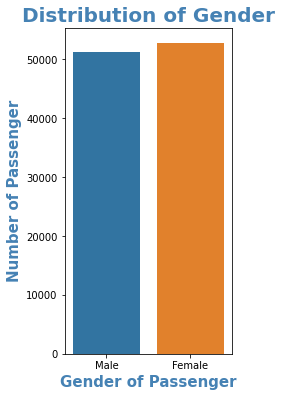


 ----- Value Counts of Gender -----

Female    52727
Male      51177
Name: Gender, dtype: int64


In [10]:
plt.figure(figsize=(3,6))
plt.title("Distribution of Gender", fontsize=20, fontweight='bold', color='steelblue')

sns.countplot(x='Gender', data=train_data)

plt.xlabel("Gender of Passenger", fontsize=15, fontweight='bold', color='steelblue')
plt.ylabel("Number of Passenger", fontsize=15, fontweight='bold', color='steelblue')
plt.show()

print("\n ----- Value Counts of Gender -----\n")
print(train_data['Gender'].value_counts())

In [11]:
train_data.Gender.value_counts(1)*100

Female    50.745881
Male      49.254119
Name: Gender, dtype: float64

        ♦ Female passengers are larger than male

###### Checking Distribution of Gender

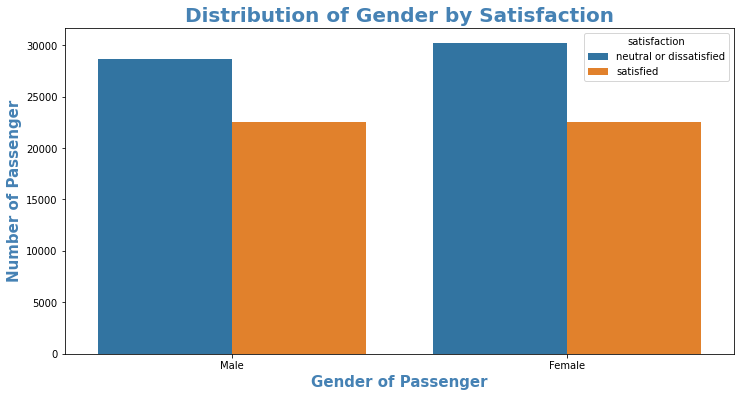


 ----- Statistical Summary of Gender -----

count     103904
unique         2
top       Female
freq       52727
Name: Gender, dtype: object


In [12]:
plt.figure(figsize=(12,6))
plt.title("Distribution of Gender by Satisfaction", fontsize=20, fontweight='bold', color='steelblue')

sns.countplot(x='Gender', data=train_data, hue='satisfaction')

plt.xlabel("Gender of Passenger", fontsize=15, fontweight='bold', color='steelblue')
plt.ylabel("Number of Passenger", fontsize=15, fontweight='bold', color='steelblue')
plt.show()

print("\n ----- Statistical Summary of Gender -----\n")
print(train_data['Gender'].describe())

#### How many of them were loyal and Disloyal customers?

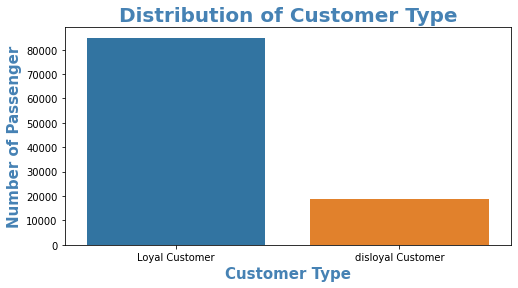


 ----- Value Counts of Customer Type -----

Loyal Customer       84923
disloyal Customer    18981
Name: Customer Type, dtype: int64


In [13]:
plt.figure(figsize=(8,4))
plt.title("Distribution of Customer Type", fontsize=20, fontweight='bold', color='steelblue')

sns.countplot(x='Customer Type', data=train_data)

plt.xlabel("Customer Type", fontsize=15, fontweight='bold', color='steelblue')
plt.ylabel("Number of Passenger", fontsize=15, fontweight='bold', color='steelblue')
plt.show()

print("\n ----- Value Counts of Customer Type -----\n")
print(train_data['Customer Type'].value_counts())

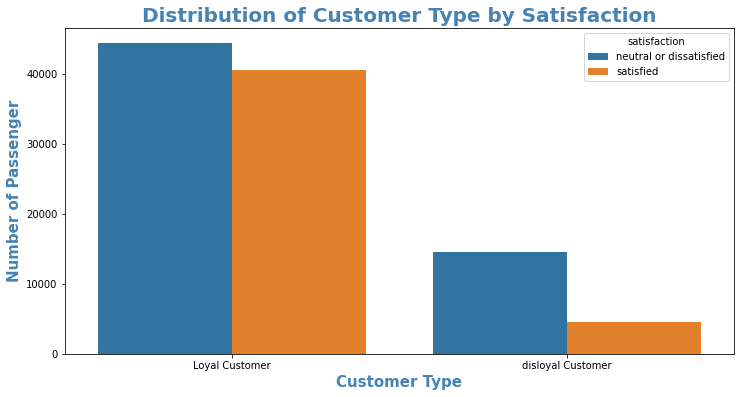


 ----- Statistical Summary of Customer Type -----

count             103904
unique                 2
top       Loyal Customer
freq               84923
Name: Customer Type, dtype: object


In [14]:
plt.figure(figsize=(12,6))
plt.title("Distribution of Customer Type by Satisfaction", fontsize=20, fontweight='bold', color='steelblue')

sns.countplot(x='Customer Type', data=train_data, hue='satisfaction')

plt.xlabel("Customer Type", fontsize=15, fontweight='bold', color='steelblue')
plt.ylabel("Number of Passenger", fontsize=15, fontweight='bold', color='steelblue')
plt.show()

print("\n ----- Statistical Summary of Customer Type -----\n")
print(train_data['Customer Type'].describe())

#### Checking Distribution of Age

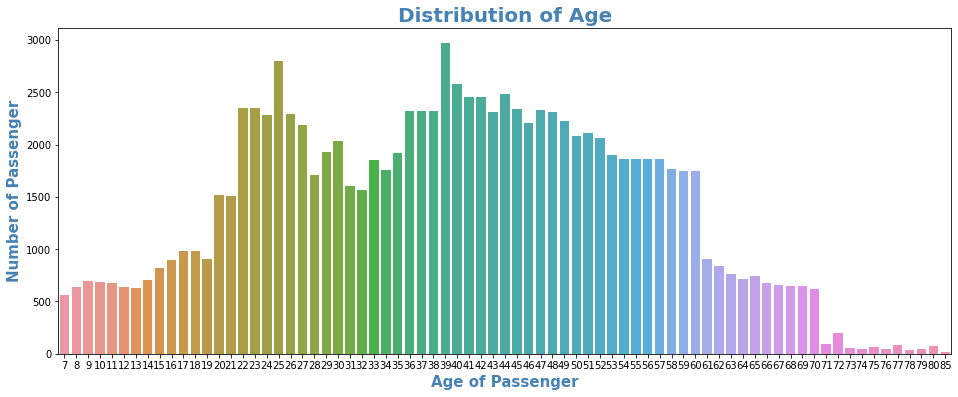


 ----- Value Counts of Age -----

39    2969
25    2798
40    2574
44    2482
42    2457
      ... 
74      47
76      45
79      42
78      33
85      17
Name: Age, Length: 75, dtype: int64


In [15]:
plt.figure(figsize=(16,6))
plt.title("Distribution of Age", fontsize=20, fontweight='bold', color='steelblue')

sns.countplot(x='Age', data=train_data)

plt.xlabel("Age of Passenger", fontsize=15, fontweight='bold', color='steelblue')
plt.ylabel("Number of Passenger", fontsize=15, fontweight='bold', color='steelblue')
plt.show()

print("\n ----- Value Counts of Age -----\n")
print(train_data['Age'].value_counts())

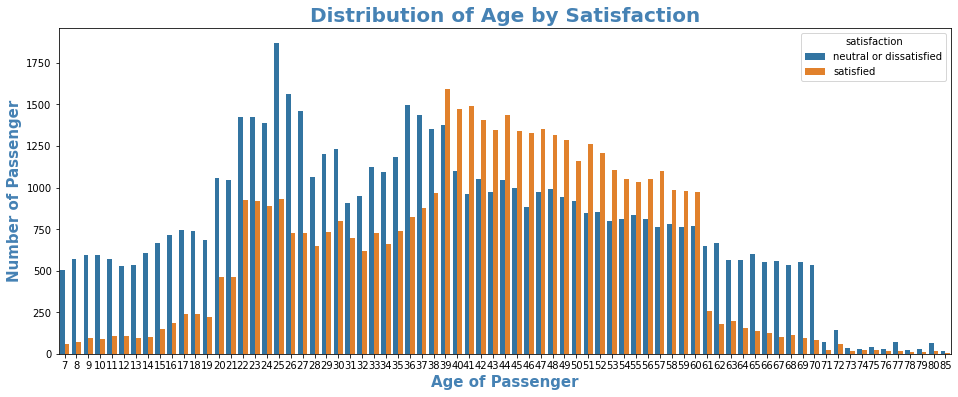


 ----- Statistical Summary of Age -----

count    103904.000000
mean         39.379706
std          15.114964
min           7.000000
25%          27.000000
50%          40.000000
75%          51.000000
max          85.000000
Name: Age, dtype: float64


In [16]:
plt.figure(figsize=(16,6))
plt.title("Distribution of Age by Satisfaction", 
          fontsize=20, fontweight='bold', color='steelblue')

sns.countplot(x='Age', data=train_data, hue='satisfaction')

plt.xlabel("Age of Passenger", fontsize=15, fontweight='bold', color='steelblue')
plt.ylabel("Number of Passenger", fontsize=15, fontweight='bold', color='steelblue')
plt.show()

print("\n ----- Statistical Summary of Age -----\n")
print(train_data['Age'].describe())

In [17]:
gender = train_data.groupby('Gender')[['Age', 'Flight Distance']].mean()
gender

,Age,Flight Distance
Gender,,
Female,39.246762,1183.723519
Male,39.516677,1195.346621


##### Which type of passengers were more satisfied ?

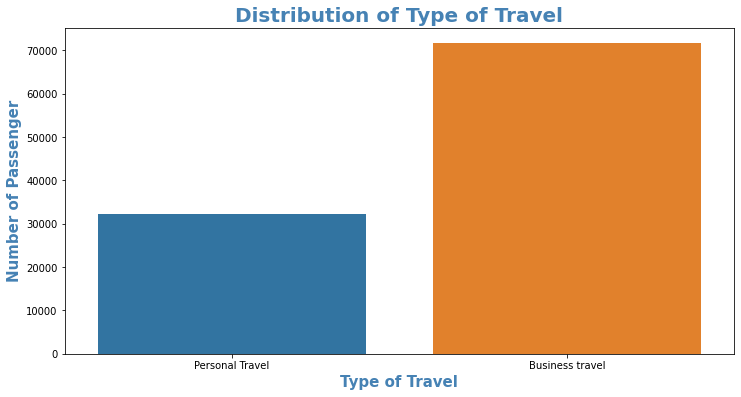


 ----- Value Counts of Type of Travel -----

Business travel    71655
Personal Travel    32249
Name: Type of Travel, dtype: int64


In [18]:
plt.figure(figsize=(12,6))
plt.title("Distribution of Type of Travel", fontsize=20, fontweight='bold', color='steelblue')

sns.countplot(x="Type of Travel", data=train_data)

plt.xlabel("Type of Travel", fontsize=15, fontweight='bold', color='steelblue')
plt.ylabel("Number of Passenger", fontsize=15, fontweight='bold', color='steelblue')
plt.show()

print("\n ----- Value Counts of Type of Travel -----\n")
print(train_data["Type of Travel"].value_counts())

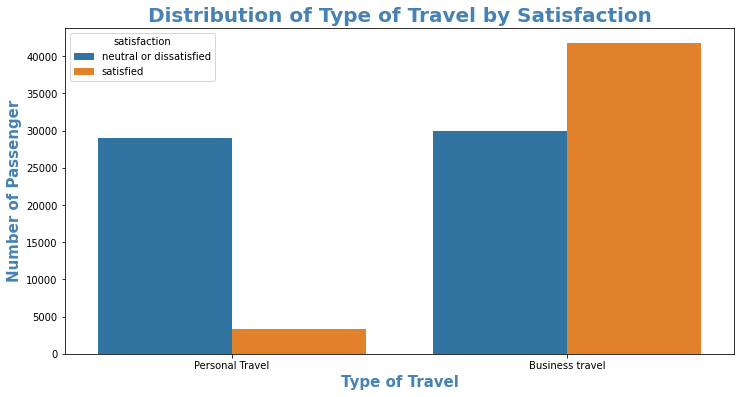


 ----- Statistical Summary of Type of Travel -----

count              103904
unique                  2
top       Business travel
freq                71655
Name: Type of Travel, dtype: object


In [19]:
plt.figure(figsize=(12,6))
plt.title("Distribution of Type of Travel by Satisfaction", fontsize=20, fontweight='bold', color='steelblue')

sns.countplot(x="Type of Travel", data=train_data, hue='satisfaction')

plt.xlabel("Type of Travel", fontsize=15, fontweight='bold', color='steelblue')
plt.ylabel("Number of Passenger", fontsize=15, fontweight='bold', color='steelblue')
plt.show()

print("\n ----- Statistical Summary of Type of Travel -----\n")
print(train_data["Type of Travel"].describe())

##### Checking Distribution of "Class"

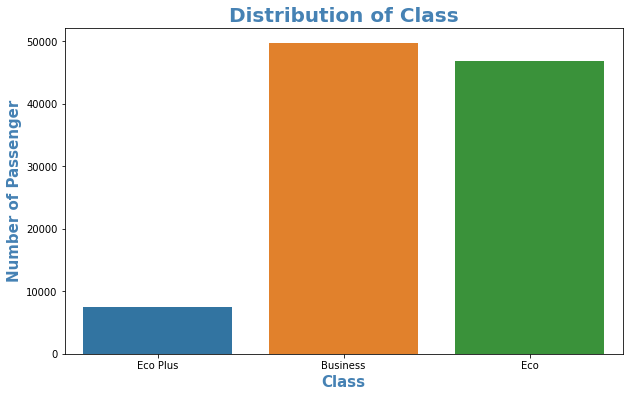


 ----- Value Counts of Class -----

Business    49665
Eco         46745
Eco Plus     7494
Name: Class, dtype: int64


In [20]:
plt.figure(figsize=(10,6))
plt.title("Distribution of Class", fontsize=20, fontweight='bold', color='steelblue')

sns.countplot(x='Class', data=train_data)

plt.xlabel("Class", fontsize=15, fontweight='bold', color='steelblue')
plt.ylabel("Number of Passenger", fontsize=15, fontweight='bold', color='steelblue')
plt.show()

print("\n ----- Value Counts of Class -----\n")
print(train_data['Class'].value_counts())

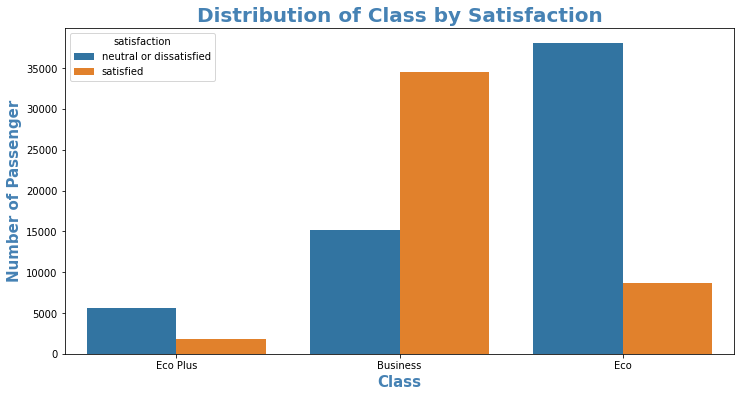


 ----- Statistical Summary of Class -----

count       103904
unique           3
top       Business
freq         49665
Name: Class, dtype: object


In [21]:
plt.figure(figsize=(12,6))
plt.title("Distribution of Class by Satisfaction", fontsize=20, fontweight='bold', color='steelblue')

sns.countplot(x='Class', data=train_data, hue='satisfaction')

plt.xlabel("Class", fontsize=15, fontweight='bold', color='steelblue')
plt.ylabel("Number of Passenger", fontsize=15, fontweight='bold', color='steelblue')
plt.show()

print("\n ----- Statistical Summary of Class -----\n")
print(train_data['Class'].describe())

##### Checking Distribution of Flight Distance by using Boxplot

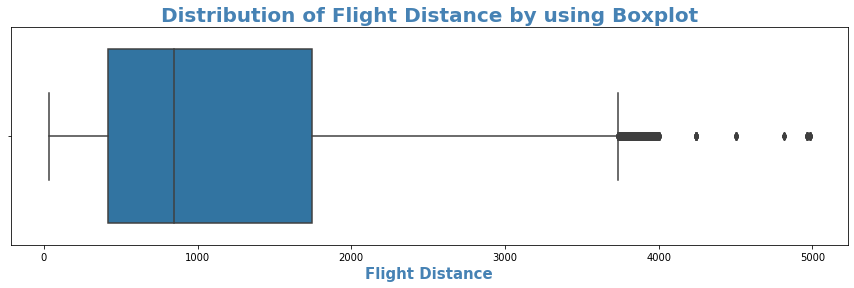


 ----- Value Counts Flight Distance -----

337     660
594     395
404     392
862     369
2475    369
       ... 
656       1
1364      1
887       1
1206      1
400       1
Name: Flight Distance, Length: 3802, dtype: int64

 ----- statistical Summary of Flight Distance -----

count    103904.000000
mean       1189.448375
std         997.147281
min          31.000000
25%         414.000000
50%         843.000000
75%        1743.000000
max        4983.000000
Name: Flight Distance, dtype: float64


In [22]:
plt.figure(figsize=(15,4))
plt.title("Distribution of Flight Distance by using Boxplot", 
          fontsize=20, fontweight='bold', color='steelblue')

sns.boxplot(train_data["Flight Distance"])

plt.xlabel("Flight Distance", fontsize=15, fontweight='bold', color='steelblue')
plt.show()

print("\n ----- Value Counts Flight Distance -----\n")
print(train_data["Flight Distance"].value_counts())
print("\n ----- statistical Summary of Flight Distance -----\n")
print(train_data['Flight Distance'].describe())

##### Checking Distribution of "Inflight wifi service"

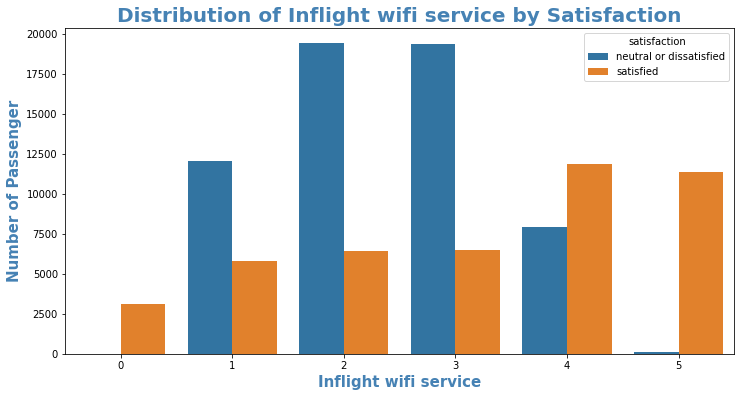


 ----- Value Counts of Inflight wifi service -----

3    25868
2    25830
4    19794
1    17840
5    11469
0     3103
Name: Inflight wifi service, dtype: int64

 ----- Statistical Summary of Inflight wifi service ----- 

count    103904.000000
mean          2.729683
std           1.327829
min           0.000000
25%           2.000000
50%           3.000000
75%           4.000000
max           5.000000
Name: Inflight wifi service, dtype: float64


In [23]:
plt.figure(figsize=(12,6))
plt.title("Distribution of Inflight wifi service by Satisfaction", fontsize=20, fontweight='bold', color='steelblue')

sns.countplot(x="Inflight wifi service", data=train_data, hue='satisfaction')

plt.xlabel("Inflight wifi service", fontsize=15, fontweight='bold', color='steelblue')
plt.ylabel("Number of Passenger", fontsize=15, fontweight='bold', color='steelblue')
plt.show()

print("\n ----- Value Counts of Inflight wifi service -----\n")
print(train_data["Inflight wifi service"].value_counts())
print("\n ----- Statistical Summary of Inflight wifi service ----- \n")
print(train_data["Inflight wifi service"].describe())

##### Checking Distribution of "Departure/Arrival time convenient"

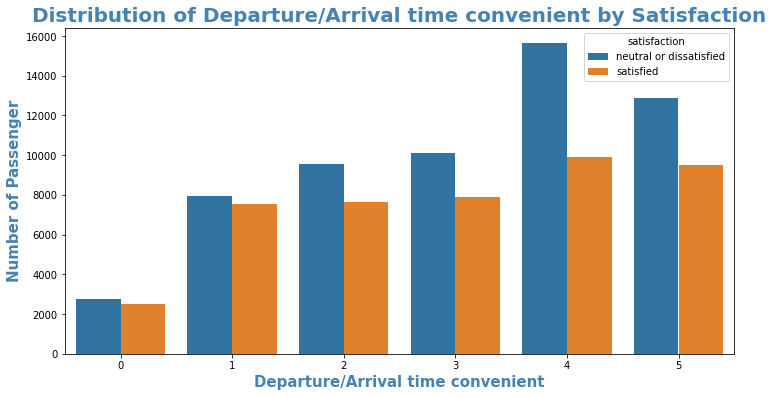


 ----- Value Counts of Departure/Arrival time convenient ----- 

4    25546
5    22403
3    17966
2    17191
1    15498
0     5300
Name: Departure/Arrival time convenient, dtype: int64

 ----- Statistical Summary of Departure/Arrival time convenient ----- 

count    103904.000000
mean          3.060296
std           1.525075
min           0.000000
25%           2.000000
50%           3.000000
75%           4.000000
max           5.000000
Name: Departure/Arrival time convenient, dtype: float64


In [24]:
plt.figure(figsize=(12,6))
plt.title("Distribution of Departure/Arrival time convenient by Satisfaction", 
          fontsize=20, fontweight='bold', color='steelblue')

sns.countplot(x="Departure/Arrival time convenient", data=train_data, hue='satisfaction')

plt.xlabel("Departure/Arrival time convenient", fontsize=15, fontweight='bold', color='steelblue')
plt.ylabel("Number of Passenger", fontsize=15, fontweight='bold', color='steelblue')
plt.show()

print("\n ----- Value Counts of Departure/Arrival time convenient ----- \n")
print(train_data["Departure/Arrival time convenient"].value_counts())
print("\n ----- Statistical Summary of Departure/Arrival time convenient ----- \n")
print(train_data["Departure/Arrival time convenient"].describe())

##### Checking Distribution of "Ease of Online booking"

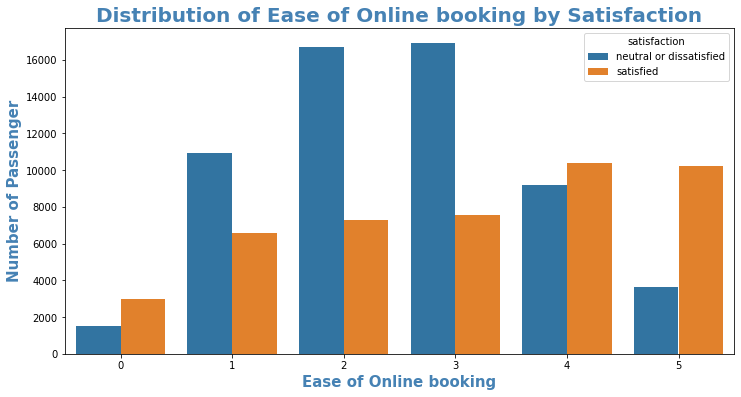


 ----- Value Counts of Ease of Online booking ----- 

3    24449
2    24021
4    19571
1    17525
5    13851
0     4487
Name: Ease of Online booking, dtype: int64

 ----- Statistical Summary of Ease of Online booking ----- 

count    103904.000000
mean          2.756901
std           1.398929
min           0.000000
25%           2.000000
50%           3.000000
75%           4.000000
max           5.000000
Name: Ease of Online booking, dtype: float64


In [25]:
plt.figure(figsize=(12,6))
plt.title("Distribution of Ease of Online booking by Satisfaction", 
          fontsize=20, fontweight='bold', color='steelblue')

sns.countplot(x="Ease of Online booking", data=train_data, hue='satisfaction')

plt.xlabel("Ease of Online booking", fontsize=15, fontweight='bold', color='steelblue')
plt.ylabel("Number of Passenger", fontsize=15, fontweight='bold', color='steelblue')
plt.show()

print("\n ----- Value Counts of Ease of Online booking ----- \n")
print(train_data["Ease of Online booking"].value_counts())
print("\n ----- Statistical Summary of Ease of Online booking ----- \n")
print(train_data["Ease of Online booking"].describe())

##### Checking Distribution of "Gate location"

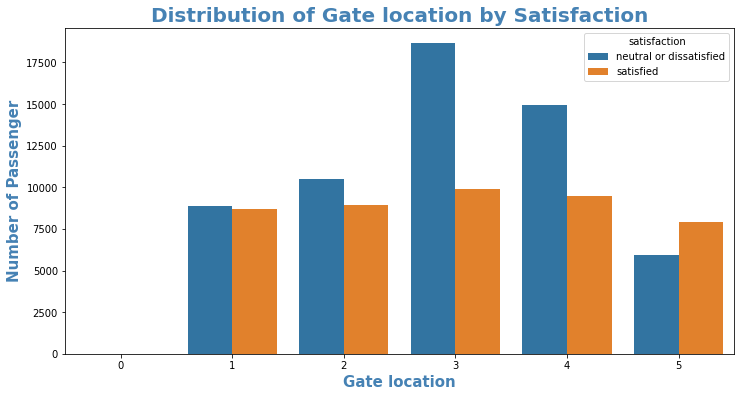


 ----- Value Counts of Gate location ----- 

3    28577
4    24426
2    19459
1    17562
5    13879
0        1
Name: Gate location, dtype: int64

 ----- Statistical Summary of Gate location ----- 

count    103904.000000
mean          2.976883
std           1.277621
min           0.000000
25%           2.000000
50%           3.000000
75%           4.000000
max           5.000000
Name: Gate location, dtype: float64


In [26]:
plt.figure(figsize=(12,6))
plt.title("Distribution of Gate location by Satisfaction", 
          fontsize=20, fontweight='bold', color='steelblue')

sns.countplot(x="Gate location", data=train_data, hue='satisfaction')

plt.xlabel("Gate location", fontsize=15, fontweight='bold', color='steelblue')
plt.ylabel("Number of Passenger", fontsize=15, fontweight='bold', color='steelblue')
plt.show()

print("\n ----- Value Counts of Gate location ----- \n")
print(train_data["Gate location"].value_counts())
print("\n ----- Statistical Summary of Gate location ----- \n")
print(train_data["Gate location"].describe())

##### Checking Distribution of "Food and drink"

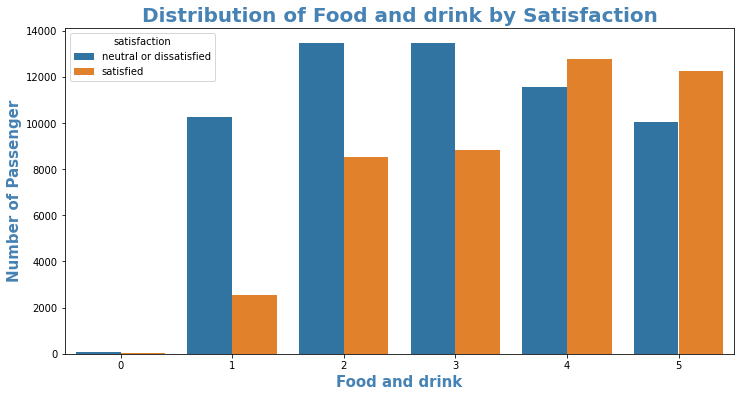


 ----- Value Counts of Food and drink ----- 

4    24359
5    22313
3    22300
2    21988
1    12837
0      107
Name: Food and drink, dtype: int64

 ----- Statistical Summary of Food and drink ----- 

count    103904.000000
mean          3.202129
std           1.329533
min           0.000000
25%           2.000000
50%           3.000000
75%           4.000000
max           5.000000
Name: Food and drink, dtype: float64


In [27]:
plt.figure(figsize=(12,6))
plt.title("Distribution of Food and drink by Satisfaction", 
          fontsize=20, fontweight='bold', color='steelblue')

sns.countplot(x="Food and drink", data=train_data, hue='satisfaction')

plt.xlabel("Food and drink", fontsize=15, fontweight='bold', color='steelblue')
plt.ylabel("Number of Passenger", fontsize=15, fontweight='bold', color='steelblue')
plt.show()

print("\n ----- Value Counts of Food and drink ----- \n")
print(train_data["Food and drink"].value_counts())
print("\n ----- Statistical Summary of Food and drink ----- \n")
print(train_data["Food and drink"].describe())

##### Checking Distribution of "Online boarding"

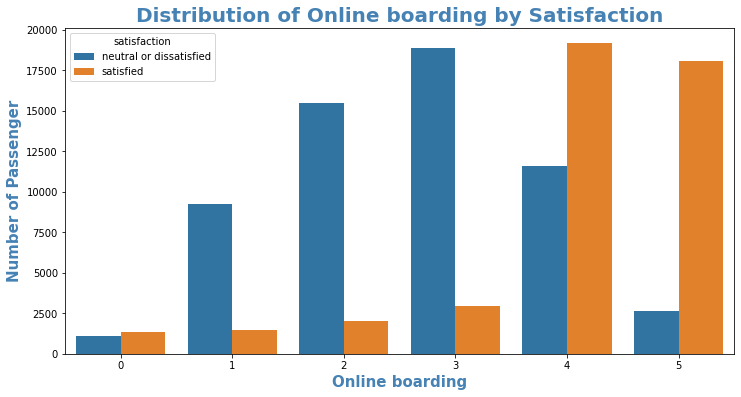


 ----- Value Counts of Online boarding ----- 

4    30762
3    21804
5    20713
2    17505
1    10692
0     2428
Name: Online boarding, dtype: int64

 ----- Statistical Summary of Online boarding ----- 

count    103904.000000
mean          3.250375
std           1.349509
min           0.000000
25%           2.000000
50%           3.000000
75%           4.000000
max           5.000000
Name: Online boarding, dtype: float64


In [28]:
plt.figure(figsize=(12,6))
plt.title("Distribution of Online boarding by Satisfaction", 
          fontsize=20, fontweight='bold', color='steelblue')

sns.countplot(x="Online boarding", data=train_data, hue='satisfaction')

plt.xlabel("Online boarding", fontsize=15, fontweight='bold', color='steelblue')
plt.ylabel("Number of Passenger", fontsize=15, fontweight='bold', color='steelblue')
plt.show()

print("\n ----- Value Counts of Online boarding ----- \n")
print(train_data["Online boarding"].value_counts())
print("\n ----- Statistical Summary of Online boarding ----- \n")
print(train_data["Online boarding"].describe())

##### Checking Distribution of "Seat comfort"

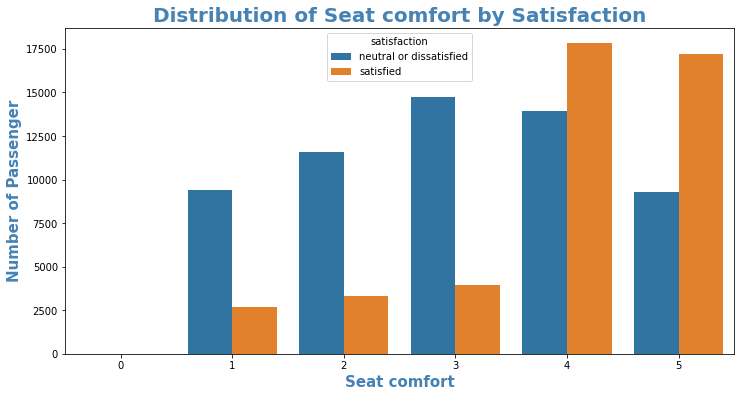


 ----- Value Counts of Seat comfort ----- 

4    31765
5    26470
3    18696
2    14897
1    12075
0        1
Name: Seat comfort, dtype: int64

 ----- Statistical Summary of Seat comfort ----- 

count    103904.000000
mean          3.439396
std           1.319088
min           0.000000
25%           2.000000
50%           4.000000
75%           5.000000
max           5.000000
Name: Seat comfort, dtype: float64


In [29]:
plt.figure(figsize=(12,6))
plt.title("Distribution of Seat comfort by Satisfaction", 
          fontsize=20, fontweight='bold', color='steelblue')

sns.countplot(x="Seat comfort", data=train_data, hue='satisfaction')

plt.xlabel("Seat comfort", fontsize=15, fontweight='bold', color='steelblue')
plt.ylabel("Number of Passenger", fontsize=15, fontweight='bold', color='steelblue')
plt.show()

print("\n ----- Value Counts of Seat comfort ----- \n")
print(train_data["Seat comfort"].value_counts())
print("\n ----- Statistical Summary of Seat comfort ----- \n")
print(train_data["Seat comfort"].describe())

##### Checking Distribution of "Inflight entertainment"

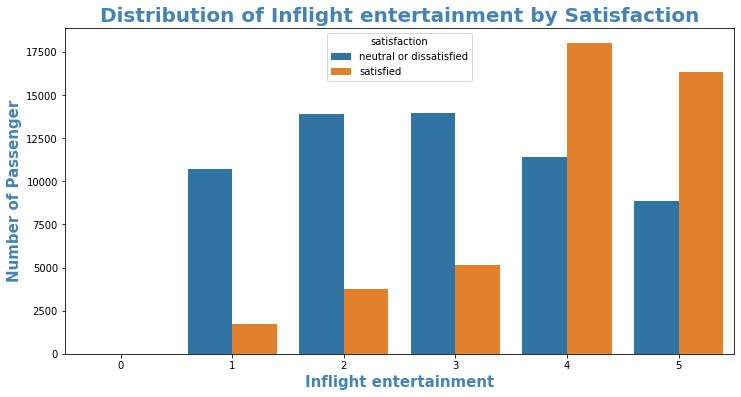


 ----- Value Counts of Inflight entertainment ----- 

4    29423
5    25213
3    19139
2    17637
1    12478
0       14
Name: Inflight entertainment, dtype: int64

 ----- Statistical Summary of Inflight entertainment ----- 

count    103904.000000
mean          3.358158
std           1.332991
min           0.000000
25%           2.000000
50%           4.000000
75%           4.000000
max           5.000000
Name: Inflight entertainment, dtype: float64


In [30]:
plt.figure(figsize=(12,6))
plt.title("Distribution of Inflight entertainment by Satisfaction", 
          fontsize=20, fontweight='bold', color='steelblue')

sns.countplot(x="Inflight entertainment", data=train_data, hue='satisfaction')

plt.xlabel("Inflight entertainment", fontsize=15, fontweight='bold', color='steelblue')
plt.ylabel("Number of Passenger", fontsize=15, fontweight='bold', color='steelblue')
plt.show()

print("\n ----- Value Counts of Inflight entertainment ----- \n")
print(train_data["Inflight entertainment"].value_counts())
print("\n ----- Statistical Summary of Inflight entertainment ----- \n")
print(train_data["Inflight entertainment"].describe())

##### Checking Distribution of "On-board service"

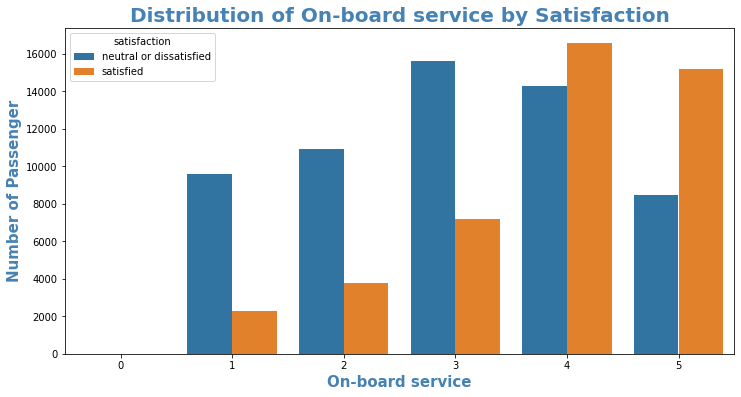


 ----- Value Counts of On-board service ----- 

4    30867
5    23648
3    22833
2    14681
1    11872
0        3
Name: On-board service, dtype: int64

 ----- Statistical Summary of On-board service ----- 

count    103904.000000
mean          3.382363
std           1.288354
min           0.000000
25%           2.000000
50%           4.000000
75%           4.000000
max           5.000000
Name: On-board service, dtype: float64


In [31]:
plt.figure(figsize=(12,6))
plt.title("Distribution of On-board service by Satisfaction", 
          fontsize=20, fontweight='bold', color='steelblue')

sns.countplot(x="On-board service", data=train_data, hue='satisfaction')

plt.xlabel("On-board service", fontsize=15, fontweight='bold', color='steelblue')
plt.ylabel("Number of Passenger", fontsize=15, fontweight='bold', color='steelblue')
plt.show()

print("\n ----- Value Counts of On-board service ----- \n")
print(train_data["On-board service"].value_counts())
print("\n ----- Statistical Summary of On-board service ----- \n")
print(train_data["On-board service"].describe())

##### Checking Distribution of "Leg room service"

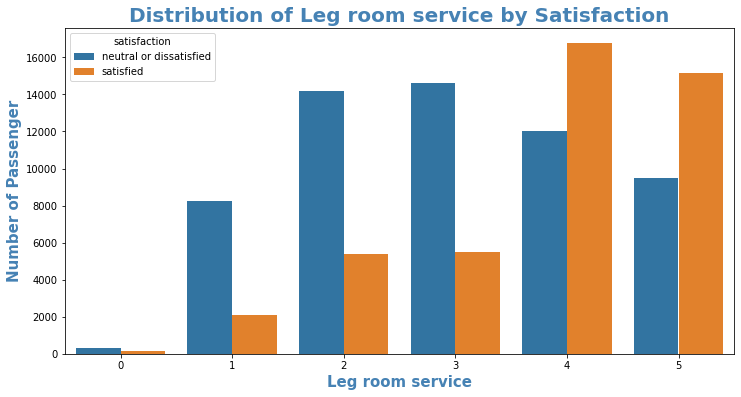


 ----- Value Counts of Leg room service ----- 

4    28789
5    24667
3    20098
2    19525
1    10353
0      472
Name: Leg room service, dtype: int64

 ----- Statistical Summary of Leg room service ----- 

count    103904.000000
mean          3.351055
std           1.315605
min           0.000000
25%           2.000000
50%           4.000000
75%           4.000000
max           5.000000
Name: Leg room service, dtype: float64


In [32]:
plt.figure(figsize=(12,6))
plt.title("Distribution of Leg room service by Satisfaction", 
          fontsize=20, fontweight='bold', color='steelblue')

sns.countplot(x="Leg room service", data=train_data, hue='satisfaction')

plt.xlabel("Leg room service", fontsize=15, fontweight='bold', color='steelblue')
plt.ylabel("Number of Passenger", fontsize=15, fontweight='bold', color='steelblue')
plt.show()

print("\n ----- Value Counts of Leg room service ----- \n")
print(train_data["Leg room service"].value_counts())
print("\n ----- Statistical Summary of Leg room service ----- \n")
print(train_data["Leg room service"].describe())

##### Checking Distribution of "Baggage handling"

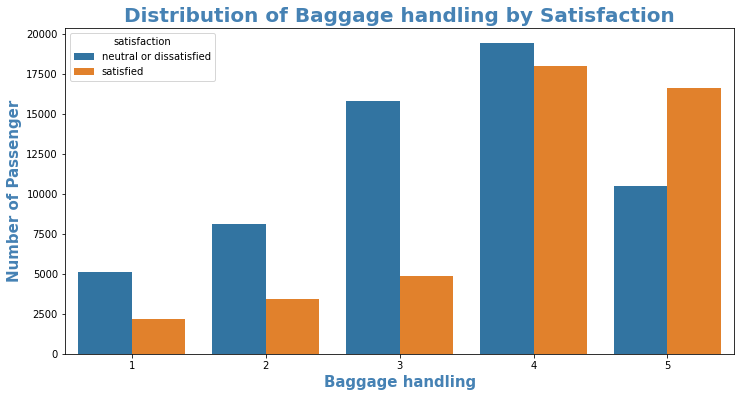


 ----- Value Counts of Baggage handling ----- 

4    37383
5    27131
3    20632
2    11521
1     7237
Name: Baggage handling, dtype: int64

 ----- Statistical Summary of Baggage handling ----- 

count    103904.000000
mean          3.631833
std           1.180903
min           1.000000
25%           3.000000
50%           4.000000
75%           5.000000
max           5.000000
Name: Baggage handling, dtype: float64


In [33]:
plt.figure(figsize=(12,6))
plt.title("Distribution of Baggage handling by Satisfaction", 
          fontsize=20, fontweight='bold', color='steelblue')

sns.countplot(x="Baggage handling", data=train_data, hue='satisfaction')

plt.xlabel("Baggage handling", fontsize=15, fontweight='bold', color='steelblue')
plt.ylabel("Number of Passenger", fontsize=15, fontweight='bold', color='steelblue')
plt.show()

print("\n ----- Value Counts of Baggage handling ----- \n")
print(train_data["Baggage handling"].value_counts())
print("\n ----- Statistical Summary of Baggage handling ----- \n")
print(train_data["Baggage handling"].describe())

##### Checking Distribution of "Checkin service"

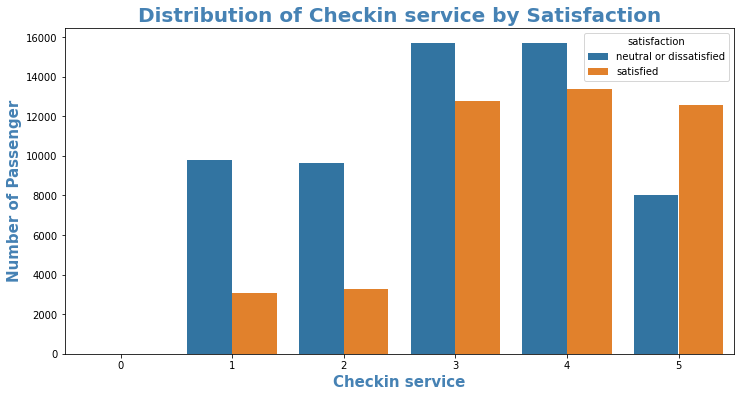


 ----- Value Counts of Checkin service ----- 

4    29055
3    28446
5    20619
2    12893
1    12890
0        1
Name: Checkin service, dtype: int64

 ----- Statistical Summary of Checkin service ----- 

count    103904.000000
mean          3.304290
std           1.265396
min           0.000000
25%           3.000000
50%           3.000000
75%           4.000000
max           5.000000
Name: Checkin service, dtype: float64


In [34]:
plt.figure(figsize=(12,6))
plt.title("Distribution of Checkin service by Satisfaction", 
          fontsize=20, fontweight='bold', color='steelblue')

sns.countplot(x="Checkin service", data=train_data, hue='satisfaction')

plt.xlabel("Checkin service", fontsize=15, fontweight='bold', color='steelblue')
plt.ylabel("Number of Passenger", fontsize=15, fontweight='bold', color='steelblue')
plt.show()

print("\n ----- Value Counts of Checkin service ----- \n")
print(train_data["Checkin service"].value_counts())
print("\n ----- Statistical Summary of Checkin service ----- \n")
print(train_data["Checkin service"].describe())

##### Checking Distribution of "Inflight service"

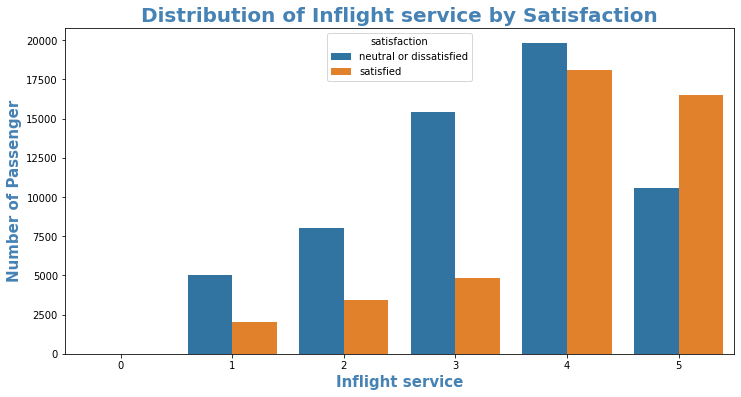


 ----- Value Counts of Inflight service ----- 

4    37945
5    27116
3    20299
2    11457
1     7084
0        3
Name: Inflight service, dtype: int64

 ----- Statistical Summary of Inflight service ----- 

count    103904.000000
mean          3.640428
std           1.175663
min           0.000000
25%           3.000000
50%           4.000000
75%           5.000000
max           5.000000
Name: Inflight service, dtype: float64


In [35]:
plt.figure(figsize=(12,6))
plt.title("Distribution of Inflight service by Satisfaction", 
          fontsize=20, fontweight='bold', color='steelblue')

sns.countplot(x="Inflight service", data=train_data, hue='satisfaction')

plt.xlabel("Inflight service", fontsize=15, fontweight='bold', color='steelblue')
plt.ylabel("Number of Passenger", fontsize=15, fontweight='bold', color='steelblue')
plt.show()

print("\n ----- Value Counts of Inflight service ----- \n")
print(train_data["Inflight service"].value_counts())
print("\n ----- Statistical Summary of Inflight service ----- \n")
print(train_data["Inflight service"].describe())

##### Checking Distribution of "Cleanliness"

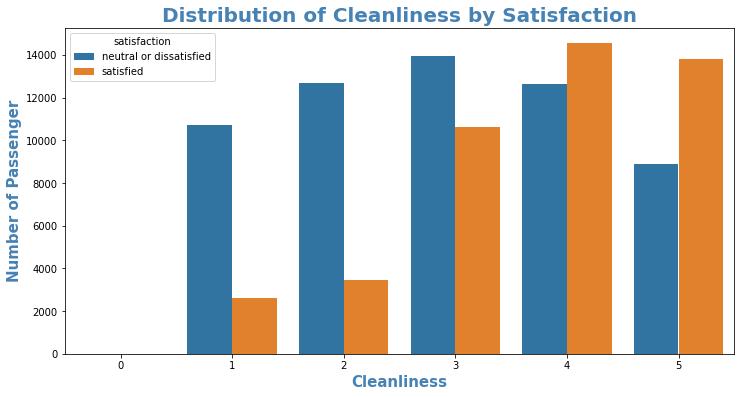


 ----- Value Counts of Cleanliness ----- 

4    27179
3    24574
5    22689
2    16132
1    13318
0       12
Name: Cleanliness, dtype: int64

 ----- Statistical Summary of Cleanliness ----- 

count    103904.000000
mean          3.286351
std           1.312273
min           0.000000
25%           2.000000
50%           3.000000
75%           4.000000
max           5.000000
Name: Cleanliness, dtype: float64


In [36]:
plt.figure(figsize=(12,6))
plt.title("Distribution of Cleanliness by Satisfaction", 
          fontsize=20, fontweight='bold', color='steelblue')

sns.countplot(x="Cleanliness", data=train_data, hue='satisfaction')

plt.xlabel("Cleanliness", fontsize=15, fontweight='bold', color='steelblue')
plt.ylabel("Number of Passenger", fontsize=15, fontweight='bold', color='steelblue')
plt.show()

print("\n ----- Value Counts of Cleanliness ----- \n")
print(train_data["Cleanliness"].value_counts())
print("\n ----- Statistical Summary of Cleanliness ----- \n")
print(train_data["Cleanliness"].describe())

##### Checking Distribution of Departure Delay in Minutes by using Boxplot 

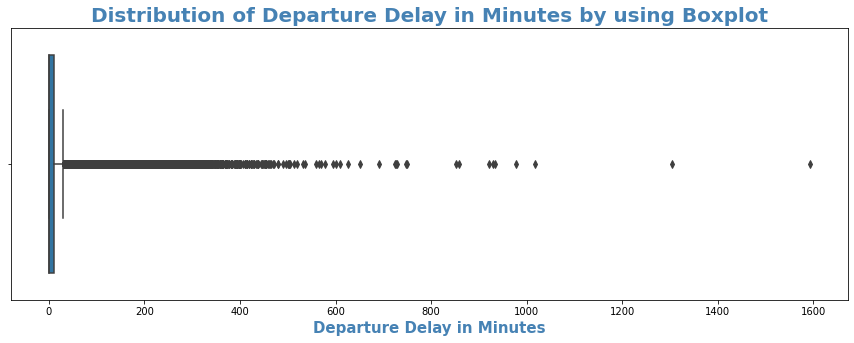


 ----- Value Counts of Departure Delay in Minutes -----

0      58668
1       2948
2       2274
3       2009
4       1854
       ...  
426        1
465        1
321        1
692        1
337        1
Name: Departure Delay in Minutes, Length: 446, dtype: int64

 ----- Statistical Summary of Departure Delay in Minutes -----

count    103904.000000
mean         14.815618
std          38.230901
min           0.000000
25%           0.000000
50%           0.000000
75%          12.000000
max        1592.000000
Name: Departure Delay in Minutes, dtype: float64


In [37]:
plt.figure(figsize=(15,5))
plt.title("Distribution of Departure Delay in Minutes by using Boxplot", 
          fontsize=20, fontweight='bold', color='steelblue')

sns.boxplot(train_data["Departure Delay in Minutes"])

plt.xlabel("Departure Delay in Minutes", fontsize=15, fontweight='bold', color='steelblue')
plt.show()

print("\n ----- Value Counts of Departure Delay in Minutes -----\n")
print(train_data["Departure Delay in Minutes"].value_counts())
print("\n ----- Statistical Summary of Departure Delay in Minutes -----\n")
print(train_data["Departure Delay in Minutes"].describe())

##### Checking Ditribution of "Arrival Delay in Minutes"

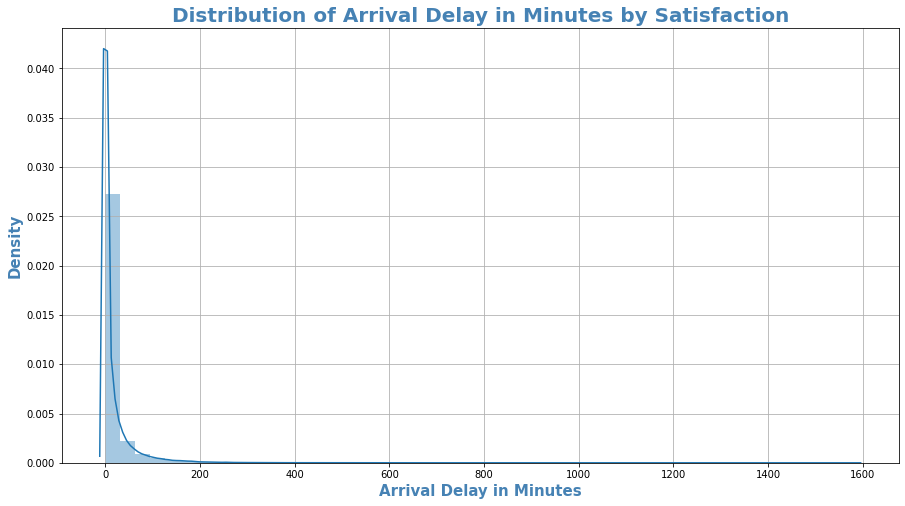


 ----- Value Counts of Arrival Delay in Minutes -----

0.0      58159
1.0       2211
2.0       2064
3.0       1952
4.0       1907
         ...  
458.0        1
729.0        1
382.0        1
459.0        1
369.0        1
Name: Arrival Delay in Minutes, Length: 456, dtype: int64

 ----- Statistical Summary of Arrival Delay in Minutes -----

count    103904.000000
mean         15.178678
std          38.640909
min           0.000000
25%           0.000000
50%           0.000000
75%          13.000000
max        1584.000000
Name: Arrival Delay in Minutes, dtype: float64


In [38]:
plt.figure(figsize=(15,8))
plt.title("Distribution of Arrival Delay in Minutes by Satisfaction", 
          fontsize=20, fontweight='bold', color='steelblue')

sns.distplot(train_data["Arrival Delay in Minutes"])

plt.xlabel("Arrival Delay in Minutes", fontsize=15, fontweight='bold', color='steelblue')
plt.ylabel("Density", fontsize=15, fontweight='bold', color='steelblue')
plt.grid()
plt.show()

print("\n ----- Value Counts of Arrival Delay in Minutes -----\n")
print(train_data["Arrival Delay in Minutes"].value_counts())
print("\n ----- Statistical Summary of Arrival Delay in Minutes -----\n")
print(train_data["Arrival Delay in Minutes"].describe())

#### How many of them were Satisfied and Neutral or Dissatisfied Passengers?

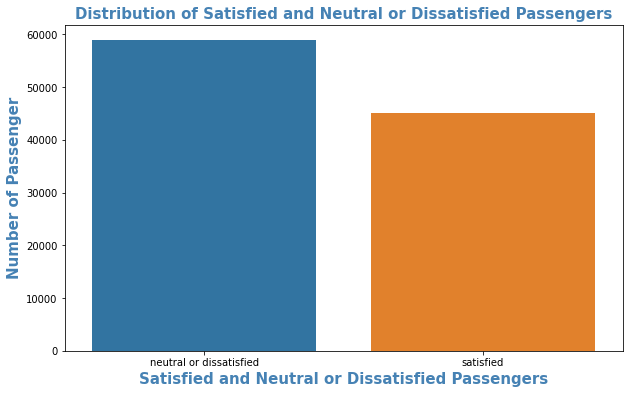


 ----- Value Counts of Satisfaction -----

neutral or dissatisfied    58879
satisfied                  45025
Name: satisfaction, dtype: int64

 ----- Statistical Summary of Satisfaction -----

count                      103904
unique                          2
top       neutral or dissatisfied
freq                        58879
Name: satisfaction, dtype: object


In [39]:
plt.figure(figsize=(10,6))
plt.title("Distribution of Satisfied and Neutral or Dissatisfied Passengers", 
          fontsize=15, fontweight='bold', color='steelblue')

sns.countplot(x='satisfaction', data=train_data)

plt.xlabel("Satisfied and Neutral or Dissatisfied Passengers", 
           fontsize=15, fontweight='bold', color='steelblue')
plt.ylabel("Number of Passenger", fontsize=15, fontweight='bold', color='steelblue')
plt.show()

print("\n ----- Value Counts of Satisfaction -----\n")
print(train_data['satisfaction'].value_counts())
print("\n ----- Statistical Summary of Satisfaction -----\n")
print(train_data['satisfaction'].describe())

##### Checking Distribution of Gender in Class

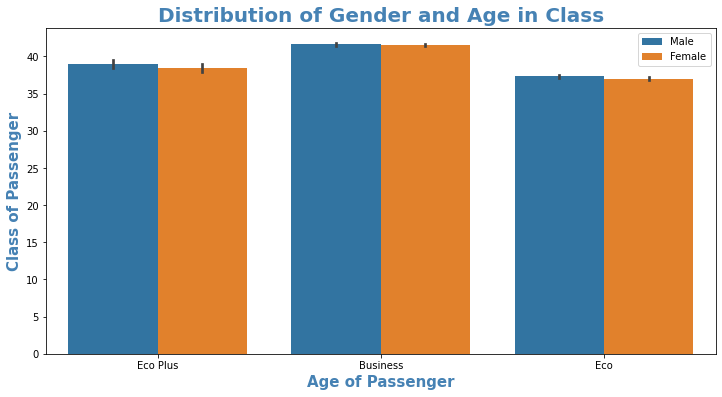

In [40]:
plt.figure(figsize=(12,6))
plt.title("Distribution of Gender and Age in Class", fontsize=20, fontweight='bold', color='steelblue')

sns.barplot(x='Class', y='Age', hue='Gender', data=train_data)

plt.xlabel("Age of Passenger", fontsize=15, fontweight='bold', color='steelblue')
plt.ylabel("Class of Passenger", fontsize=15, fontweight='bold', color='steelblue')
plt.legend(loc=1)
plt.show()

##### Checking Distribution between Age and Class by using histogram

In [41]:
Eco_Plus = train_data[train_data.Class == 'Eco Plus']
Business = train_data[train_data.Class == 'Business Class']
Eco = train_data[train_data.Class == 'Eco']

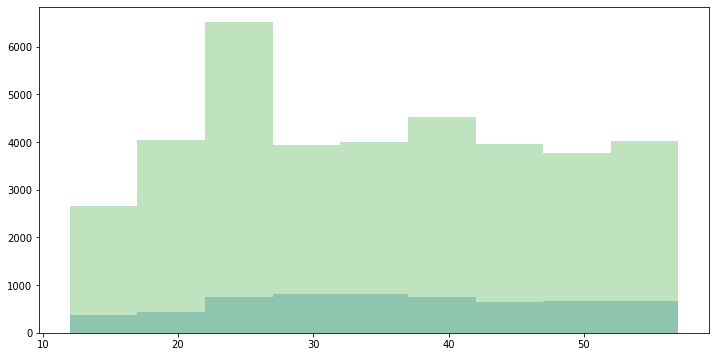

In [42]:
plt.figure(figsize=(12,6))
plt.hist(Eco_Plus.Age, alpha=0.3, bins=np.arange(12, 60, 5))
plt.hist(Business.Age, alpha=0.3, bins=np.arange(12, 60, 5))
plt.hist(Eco.Age, alpha=0.3, bins=np.arange(12, 60, 5))
plt.show()

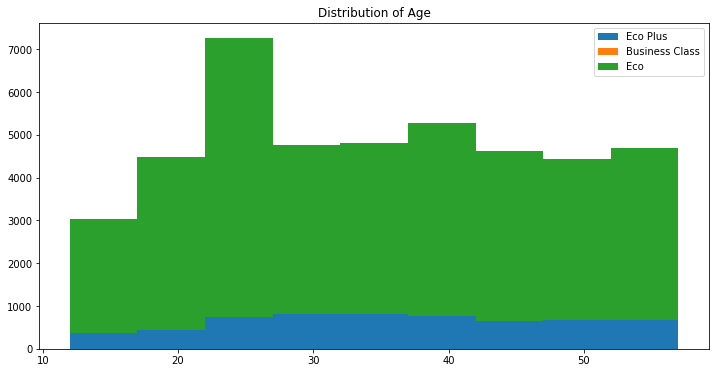

In [43]:
plt.figure(figsize=(12,6))
plt.title("Distribution of Age")
plt.hist([Eco_Plus.Age, Business.Age, Eco.Age], bins=np.arange(12, 60, 5), stacked=True)
plt.legend(["Eco Plus", "Business Class", "Eco"])
plt.show()

#### Checking Ditribution of Gate location and Baggage handling by Class

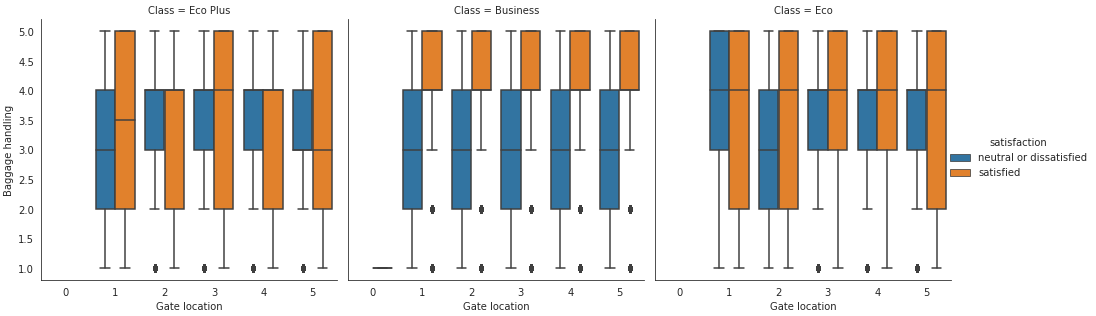

In [44]:
with sns.axes_style('white'):
    g = sns.catplot(x="Gate location", y="Baggage handling", hue="satisfaction", 
                    col="Class", data=train_data, kind="box", height=4.5, aspect=1.0)
plt.show()

#### Checking Correlation

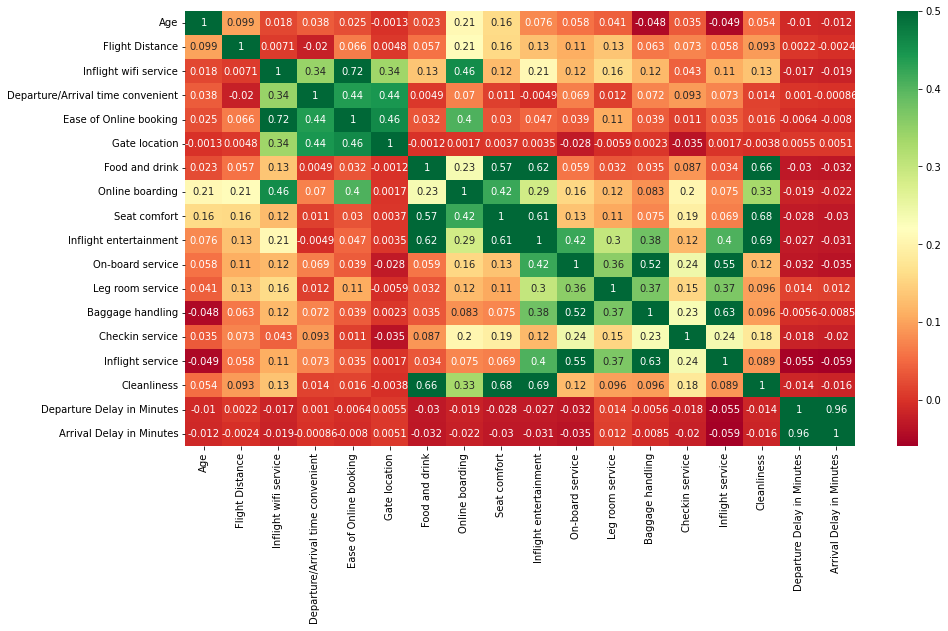

In [45]:
plt.figure(figsize=(15,8))
sns.heatmap(train_data.corr(), annot=True, cmap='RdYlGn', vmax=.5)
plt.show()

We can see that "Departure Delay in Minutes" is highly correlated with "Arrival Delay in Minutes" and "Inflight wifi service" is highly correlated with "Ease of Online booking". But no pair is having corrrelation coefficient exactly equal to 1. Therefore there is no perfect multi-collinearity. Hence we are not discarding any variable.

### Data Preprocessing

In [46]:
train_data.head()

,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,Gate location,...,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,satisfaction
0,Male,Loyal Customer,13,Personal Travel,Eco Plus,460,3,4,3,1,...,5,4,3,4,4,5,5,25,18.0,neutral or dissatisfied
1,Male,disloyal Customer,25,Business travel,Business,235,3,2,3,3,...,1,1,5,3,1,4,1,1,6.0,neutral or dissatisfied
2,Female,Loyal Customer,26,Business travel,Business,1142,2,2,2,2,...,5,4,3,4,4,4,5,0,0.0,satisfied
3,Female,Loyal Customer,25,Business travel,Business,562,2,5,5,5,...,2,2,5,3,1,4,2,11,9.0,neutral or dissatisfied
4,Male,Loyal Customer,61,Business travel,Business,214,3,3,3,3,...,3,3,4,4,3,3,3,0,0.0,satisfied


In [47]:
df = train_data[["Age", "Flight Distance"]]
df

,Age,Flight Distance
0,13,460
1,25,235
2,26,1142
3,25,562
4,61,214
...,...,...
103899,23,192
103900,49,2347
103901,30,1995
103902,22,1000


##### Computing VIF(Variance Inflation Factor) for detecting multicollinearity

In [58]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

vif = pd.DataFrame()
vif["Vif"] = [variance_inflation_factor(df, i) for i in range(df.shape[1])]
vif["Features"] = df.columns

vif

,Vif,Features
0,2.198534,Age
1,2.198534,Flight Distance


♦ VIF(Variance Inflation Factor) of all features are less than 5 so we consider all features as relavant features for modelling.

### Using the elbow method to find the optimal number of clusters

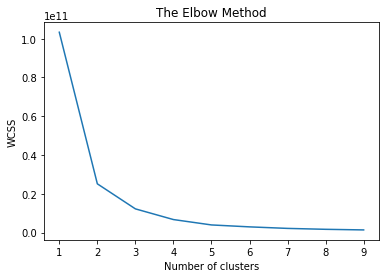

In [59]:
from sklearn.cluster import KMeans
wcss = []
for i in range(1, 10):
    kmeans = KMeans(n_clusters = i, init = 'k-means++', random_state = 42)
    kmeans.fit(df)
    wcss.append(kmeans.inertia_)
plt.plot(range(1, 10), wcss)
plt.title('The Elbow Method')
plt.xlabel('Number of clusters')
plt.ylabel('WCSS')
plt.show()

### Training the K-Means model on the dataset

In [60]:
kmeans = KMeans(n_clusters = 2, init = 'k-means++', random_state = 42)
kmeans

KMeans(n_clusters=2, random_state=42)

In [61]:
y_kmeans = kmeans.fit_predict(X)

In [62]:
y_kmeans

array([0, 0, 0, ..., 1, 0, 0])

#### Visualising the clusters

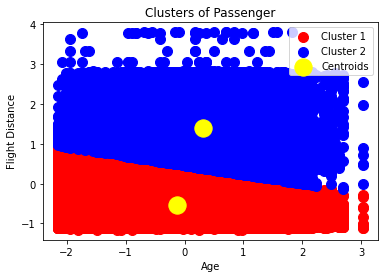

In [63]:
plt.scatter(X[y_kmeans == 0, 0], X[y_kmeans == 0, 1], s = 100, c = 'red', label = 'Cluster 1')
plt.scatter(X[y_kmeans == 1, 0], X[y_kmeans == 1, 1], s = 100, c = 'blue', label = 'Cluster 2')

plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1], s = 300, c = 'yellow', label = 'Centroids')

plt.title("Clusters of Passenger")
plt.xlabel("Age")
plt.ylabel("Flight Distance")
plt.legend()
plt.show()